******Analisis Performa Penjualan dan Segmentasi Pelanggan RetailCo******

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df_transaksi = pd.read_csv(r'D:\12345678 porto\archive (7)\retailco\retailco_transactions_data.csv')
df_customer = pd.read_csv(r'D:\12345678 porto\archive (7)\retailco\retailco_customer_data.csv')
df_store = pd.read_csv(r'D:\12345678 porto\archive (7)\retailco\retailco_store_data.csv')

print(df_transaksi.head())

  invoice_id invoice_date posting_date store_id customer_id product_id  \
0  INV000001   2024-03-23   2024-03-25     S005        C001       P020   
1  INV000002   2024-02-27   2024-02-28     S003        C031       P002   
2  INV000003   2024-02-13   2024-02-16     S004        C009       P025   
3  INV000004   2024-12-03   2024-12-04     S005        C022       P009   
4  INV000005   2024-04-18   2024-04-20     S002        C040       P013   

   quantity  unit_price  gross_amount  discount_amount  net_amount created_by  
0         6      249000       1494000         201300.0   1292700.0   u_andika  
1         4      299000       1196000         108000.0   1088000.0    u_bella  
2         9      149000       1341000         194900.0   1146100.0    u_citra  
3         9      299000       2691000         556000.0   2135000.0     u_gita  
4         6      249000       1494000         124900.0   1369100.0    u_hanif  


In [5]:
df_gabung = pd.merge(df_transaksi, df_store, on='store_id', how='left')
df_final = pd.merge(df_gabung, df_customer, on='customer_id', how='left')

print(df_final.columns.tolist())

['invoice_id', 'invoice_date', 'posting_date', 'store_id', 'customer_id', 'product_id', 'quantity', 'unit_price', 'gross_amount', 'discount_amount', 'net_amount', 'created_by', 'store_name', 'city', 'region', 'customer_name', 'customer_type', 'join_date']


In [6]:
print(df_final.isna().sum())

invoice_id         0
invoice_date       0
posting_date       0
store_id           0
customer_id        0
product_id         0
quantity           0
unit_price         0
gross_amount       0
discount_amount    0
net_amount         0
created_by         0
store_name         0
city               0
region             0
customer_name      0
customer_type      0
join_date          0
dtype: int64


In [7]:
print(df_final.info())

<class 'pandas.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   invoice_id       750 non-null    str    
 1   invoice_date     750 non-null    str    
 2   posting_date     750 non-null    str    
 3   store_id         750 non-null    str    
 4   customer_id      750 non-null    str    
 5   product_id       750 non-null    str    
 6   quantity         750 non-null    int64  
 7   unit_price       750 non-null    int64  
 8   gross_amount     750 non-null    int64  
 9   discount_amount  750 non-null    float64
 10  net_amount       750 non-null    float64
 11  created_by       750 non-null    str    
 12  store_name       750 non-null    str    
 13  city             750 non-null    str    
 14  region           750 non-null    str    
 15  customer_name    750 non-null    str    
 16  customer_type    750 non-null    str    
 17  join_date        750 non-nu

In [8]:
print("Jumlah data duplikat:", df_final.duplicated().sum())

Jumlah data duplikat: 0


##**EDA MULTIVARIAT**##

In [9]:
pivot_kota = df_final.pivot_table(
    index='city', 
    values=['net_amount', 'quantity'], 
    aggfunc='sum'
).reset_index()
print(pivot_kota)

       city   net_amount  quantity
0   Bandung  156690900.0       758
1  Denpasar  153933900.0       856
2   Jakarta  164526700.0       837
3     Medan  165575100.0       862
4  Surabaya  181518400.0       908


##**ANALISIS BIVARIATE**##

In [10]:
pivot_customer = df_final.pivot_table(
    index='customer_type', 
    values='net_amount', 
    aggfunc='sum'
).reset_index()

#ascending
pivot_customer = pivot_customer.sort_values(by='net_amount', ascending=False)

print(pivot_customer)

  customer_type   net_amount
1        Retail  328755800.0
0        Online  252739200.0
2     Wholesale  240750000.0


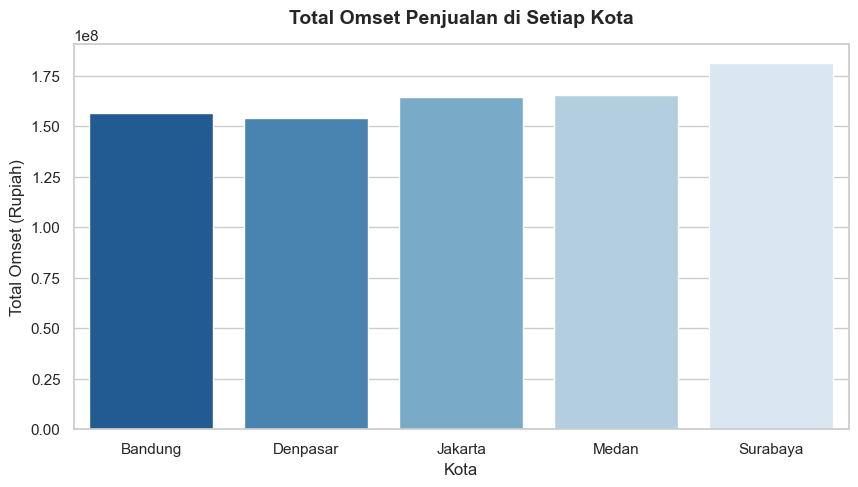

In [11]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 5))

sns.barplot(
    data=pivot_kota, 
    x='city', 
    y='net_amount', 
    hue='city',       
    palette='Blues_r', 
    legend=False     
)
plt.title('Total Omset Penjualan di Setiap Kota', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Kota', fontsize=12)
plt.ylabel('Total Omset (Rupiah)', fontsize=12)

plt.show()

**INSIGHT**


1. Surabaya merupakan penjualan terbanyak (908 pcs) dan omset tertinggi (Rp 181,5 Juta).
2. Denpasar menjual barang lebih banyak (856 pcs) daripada Bandung (758 pcs). Namun, omset uang dari Bandung justru lebih besar sebesar Rp 156,6 Juta dibandingkan dengan Denpasar sebesar Rp 153,9 Juta. Hal ini berarti rata-rata harga produk yang dibeli orang Bandung jauh lebih mahal daripada orang Denpasar. Sehingga orang Denpasar beli banyak barang tapi nyari yang murah/diskonan, sedangkan orang Bandung beli sedikit tapi barang premium/lebih mahal.
3. Segmentasi pelanggan offline menyumbang angka terbesar yaitu Rp 328,7 Juta, kemudian online sebesar Rp 252,7 Juta dan grosir sebesar Rp 240,7 Juta.

**REKOMENDASI BISNIS**

1. Karena daya beli per produk di Bandung paling tinggi, fokuskan pemasaran barang-barang dengan margin tinggi atau paket bundling eksklusif di kota Bandung.
2. Kurangi promo potongan harga langsung di Denpasar karena volume transaksi mereka sudah tinggi. Ganti promonya menjadi seperti promo minimal belanja.
3. Buat program member/loyalitas poin terintegrasi agar pelanggan toko offline tertarik mencoba belanja via online dan sebaliknya.

In [13]:
df_final.to_csv('retailco_final_clean.csv', index=False)

**Github Link looker(Dashboard)**

https://datastudio.google.com/reporting/6a9e2a7d-7cb2-4ac4-ba67-d1c655c85db0